In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from io import StringIO
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score , classification_report, confusion_matrix , f1_score, roc_auc_score , roc_curve, balanced_accuracy_score )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

**Consumo de eletrônicos tecnológicos pelo mundo nos últimos 10 anos**


In [ ]:
df = pd.read_csv("Global_Tech_Gadget_Consumption.csv")

df.head()


,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   110 non-null    object 
 1   Year                                      110 non-null    int64  
 2   Smartphone Sales (Millions)               110 non-null    float64
 3   Laptop Shipments (Millions)               110 non-null    float64
 4   Gaming Console Adoption (%)               110 non-null    float64
 5   Smartwatch Penetration (%)                110 non-null    float64
 6   Average Consumer Spending on Gadgets ($)  110 non-null    float64
 7   E-Waste Generated (Metric Tons)           110 non-null    float64
 8   5G Penetration Rate (%)                   110 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 7.9+ KB


In [ ]:
display(df.describe())

,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
count,110.00000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,2020.00000,269.095545,86.082000,21.753545,14.129818,1571.539182,1035.352636,42.816273
std,3.17675,128.313552,36.429392,9.748557,6.353190,816.552255,562.591157,21.888573
min,2015.00000,64.000000,20.790000,5.490000,2.040000,220.090000,111.470000,2.990000
25%,2017.00000,156.910000,59.412500,13.737500,8.982500,856.957500,570.250000,23.952500
50%,2020.00000,253.435000,87.450000,20.365000,14.520000,1592.145000,1023.270000,45.735000
75%,2023.00000,376.255000,113.965000,28.460000,19.815000,2195.960000,1487.847500,58.900000
max,2025.00000,499.890000,149.210000,39.470000,24.810000,2989.540000,1962.590000,79.340000


In [ ]:
print(df.isnull().sum())
df = df.drop_duplicates()

Country                                     0
Year                                        0
Smartphone Sales (Millions)                 0
Laptop Shipments (Millions)                 0
Gaming Console Adoption (%)                 0
Smartwatch Penetration (%)                  0
Average Consumer Spending on Gadgets ($)    0
E-Waste Generated (Metric Tons)             0
5G Penetration Rate (%)                     0
dtype: int64


**Colunas:**

País - Ano - Vendas de Smartphones (em milhões) - Envios de Laptops (em milhões) - Adoção de Consoles de Videogame (em %) - Penetração de Smartwatches (em %) - Gasto Médio do Consumidor em Gadgets (em dólares) - Lixo Eletrônico Gerado (em toneladas métricas) - Taxa de Penetração do 5G (em %)

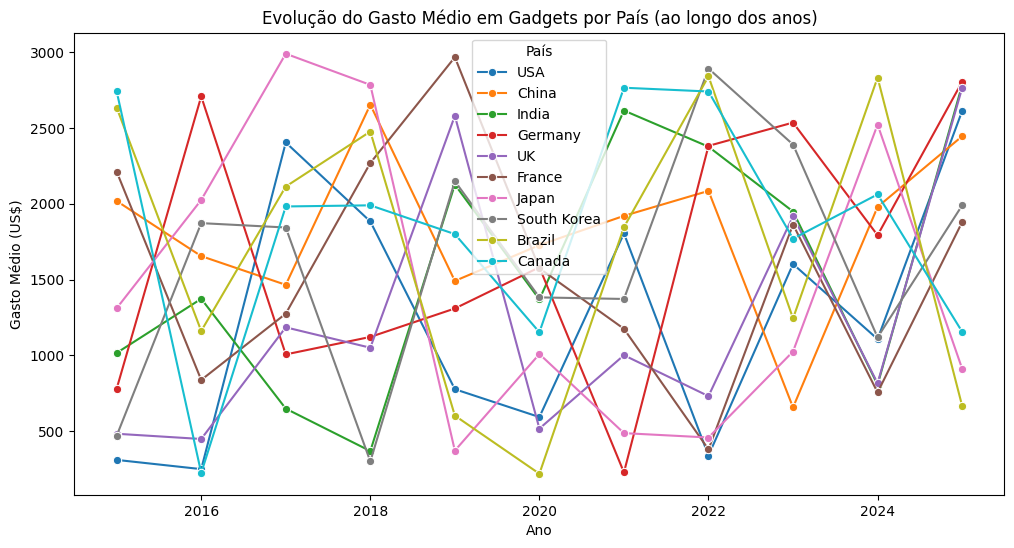

In [ ]:
# Gráfico 1: Evolução do gasto médio por país ao longo dos anos
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Year", y="Average Consumer Spending on Gadgets ($)", hue="Country", marker="o")
plt.title("Evolução do Gasto Médio em Gadgets por País (ao longo dos anos)")
plt.ylabel("Gasto Médio (US$)")
plt.xlabel("Ano")
plt.legend(title="País")
plt.show()


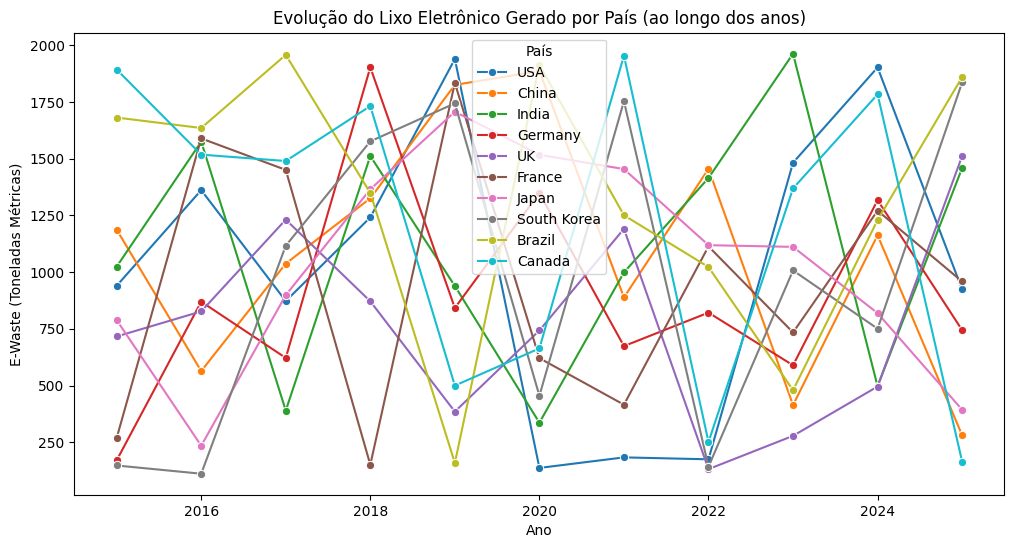

In [ ]:
# Gráfico 2: Evolução do e-waste gerado por país ao longo dos anos
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="Year", y="E-Waste Generated (Metric Tons)", hue="Country", marker="o")
plt.title("Evolução do Lixo Eletrônico Gerado por País (ao longo dos anos)")
plt.ylabel("E-Waste (Toneladas Métricas)")
plt.xlabel("Ano")
plt.legend(title="País")
plt.show()

In [ ]:

# Agrupar por país: calcular média de gasto médio e e-waste
rank_df = df.groupby("Country")[["Average Consumer Spending on Gadgets ($)", "E-Waste Generated (Metric Tons)"]].mean()

# Criar rankings: maior gasto = rank 1, maior e-waste = rank 1
rank_df["Rank_Gasto"] = rank_df["Average Consumer Spending on Gadgets ($)"].rank(method="dense", ascending=False)
rank_df["Rank_Ewaste"] = rank_df["E-Waste Generated (Metric Tons)"].rank(method="dense", ascending=False)

# Diferença absoluta entre rankings
rank_df["Diferença_Rank"] = abs(rank_df["Rank_Gasto"] - rank_df["Rank_Ewaste"])

# Ordenar: países com ciclos mais parecidos primeiro
rank_df_sorted = rank_df.sort_values("Diferença_Rank")

# Exibir tabela
print(rank_df_sorted)

             Average Consumer Spending on Gadgets ($)  \
Country                                                 
UK                                        1227.135455   
Canada                                    1853.297273   
France                                    1562.700909   
Brazil                                    1694.451818   
South Korea                               1616.678182   
China                                     1827.165455   
Japan                                     1445.444545   
India                                     1585.019091   
USA                                       1244.253636   
Germany                                   1659.245455   

             E-Waste Generated (Metric Tons)  Rank_Gasto  Rank_Ewaste  \
Country                                                                 
UK                                762.036364        10.0         10.0   
Canada                           1210.844545         1.0          2.0   
France                 

**Interpretação Detalhada por País**

Reino Unido (UK)
- Gasto Médio: ~US$ 1.227, baixo comparado a outros países da lista.
- E-Waste: ~762 toneladas, também baixo.

- Ranking: Gasto 10º ↔ E-Waste 10º → totalmente alinhado. Interpretação:
O Reino Unido aparece com baixo consumo e baixo descarte, mantendo um ciclo equilibrado.
Isso pode indicar: 1) Menor poder de compra médio em relação a países como Canadá. 2) Programas de reciclagem que reduzem o lixo eletrônico. 3) Um mercado mais maduro, em que as pessoas compram menos gadgets desnecessários.

Canadá
- Gasto Médio: ~US$ 1.853, o mais alto da lista.
- E-Waste: ~1.210 toneladas, também elevado.
- Ranking: Gasto 1º ↔ E-Waste 2º → quase alinhado. Interpretação:
O Canadá é campeão em gasto médio, e isso se reflete no alto lixo eletrônico.
Consumidores canadenses compram mais gadgets caros, elevando o ticket médio.
O descarte acompanha o consumo, mas ligeiramente menor no ranking, o que pode indicar alguma eficiência em descarte/reciclagem.

França
- Gasto Médio: ~US$ 1.562, nível intermediário-alto.
- E-Waste: ~946 toneladas, também intermediário.
- Ranking: Gasto 7º ↔ E-Waste 8º → praticamente alinhado. Interpretação:
A França mantém um ciclo equilibrado: quem gasta mais também gera mais lixo eletrônico, em proporções semelhantes.
Indica um consumo relativamente estável.
A diferença de apenas 1 no ranking mostra que o país não destoa muito entre consumo e descarte.

Brasil
- Gasto Médio: ~US$ 1.694, relativamente alto.
- E-Waste: ~1.321 toneladas, o mais alto da lista.
- Ranking: Gasto 3º ↔ E-Waste 1º → diferença de 2. Interpretação:
O Brasil aparece como um país onde gera-se muito mais lixo eletrônico em relação ao gasto médio. Isso pode indicar menor reaproveitamento de dispositivos. Possível mercado de reposição rápida (compra-se gadgets mais baratos que quebram logo, gerando mais lixo). Políticas fracas de reciclagem eletrônica também podem explicar o ranking mais alto em e-waste.

China
- Gasto Médio: ~US$ 1.827, segundo maior da lista.
- E-Waste: ~1.093 toneladas, também alto.
- Ranking: Gasto 2º ↔ E-Waste 4º → diferença de 2. Interpretação:
A China apresenta alto gasto médio, mas seu e-waste é relativamente menor no ranking. Isso pode estar ligado à produção interna: consumidores compram muito, mas parte significativa pode ser reciclada ou recondicionada internamente. Outra hipótese: embora a China consuma muito, a população gigantesca dilui a média, e há mais mercado de segunda mão (revenda de usados).

Diferente do Brasil, aqui o consumo é alto, mas o lixo eletrônico não cresce na mesma proporção.

**Logo:**
a) Mais equilibrados: Reino Unido e França (gasto e e-waste crescem juntos).

b) Maior consumo: Canadá (campeão em gasto e quase em lixo eletrônico).

c) Mais críticos: Brasil (gera mais lixo eletrônico do que seria esperado pelo nível de gasto).

d) Mais eficiente: China (alto gasto, mas menos lixo proporcionalmente).

In [ ]:
def preprocess(df):
    # 1) Ordenar por País e Ano
    df = df.sort_values(["Country", "Year"]).copy()

    # 2) Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # 3) Deltas ano a ano por país
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # 4) Classe alvo (NOVA REGRA):
    #    1 = Verde  se ΔSpending > 0 e ΔEwaste > 0
    #    0 = Sujo   se ΔSpending > 0 e ΔEwaste ≤ 0
    #    anos com ΔSpending ≤ 0 ficam sem rótulo
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # 5) Seleção de features (mesmas de antes)
    features = [
        "Smartphone Sales (Millions)",
        "Laptop Shipments (Millions)",
        "Gaming Console Adoption (%)",
        "Smartwatch Penetration (%)",
        "5G Penetration Rate (%)",
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y



In [ ]:
X, y = preprocess(df)



**NOTA:** O Modelo avalia se o crescimento de gastos acompanha o crescimento de e-waste, de forma sustentável. Ou seja, se os gastos aumentam, mas o e-waste não, então o crescimento não é sustentável. Note que se não há crescimento econômico no setor de gadgets, dizer que foi “verde” pode soar estranho, porque não houve crescimento a ser classificado. O critério de “verde/sujo” está ligado à relação entre gasto e lixo, não ao crescimento econômico em si.

Para melhor compreensão o modelo, podemos **analisar as variávies** do dataframe que **afetam** o **resultado**:

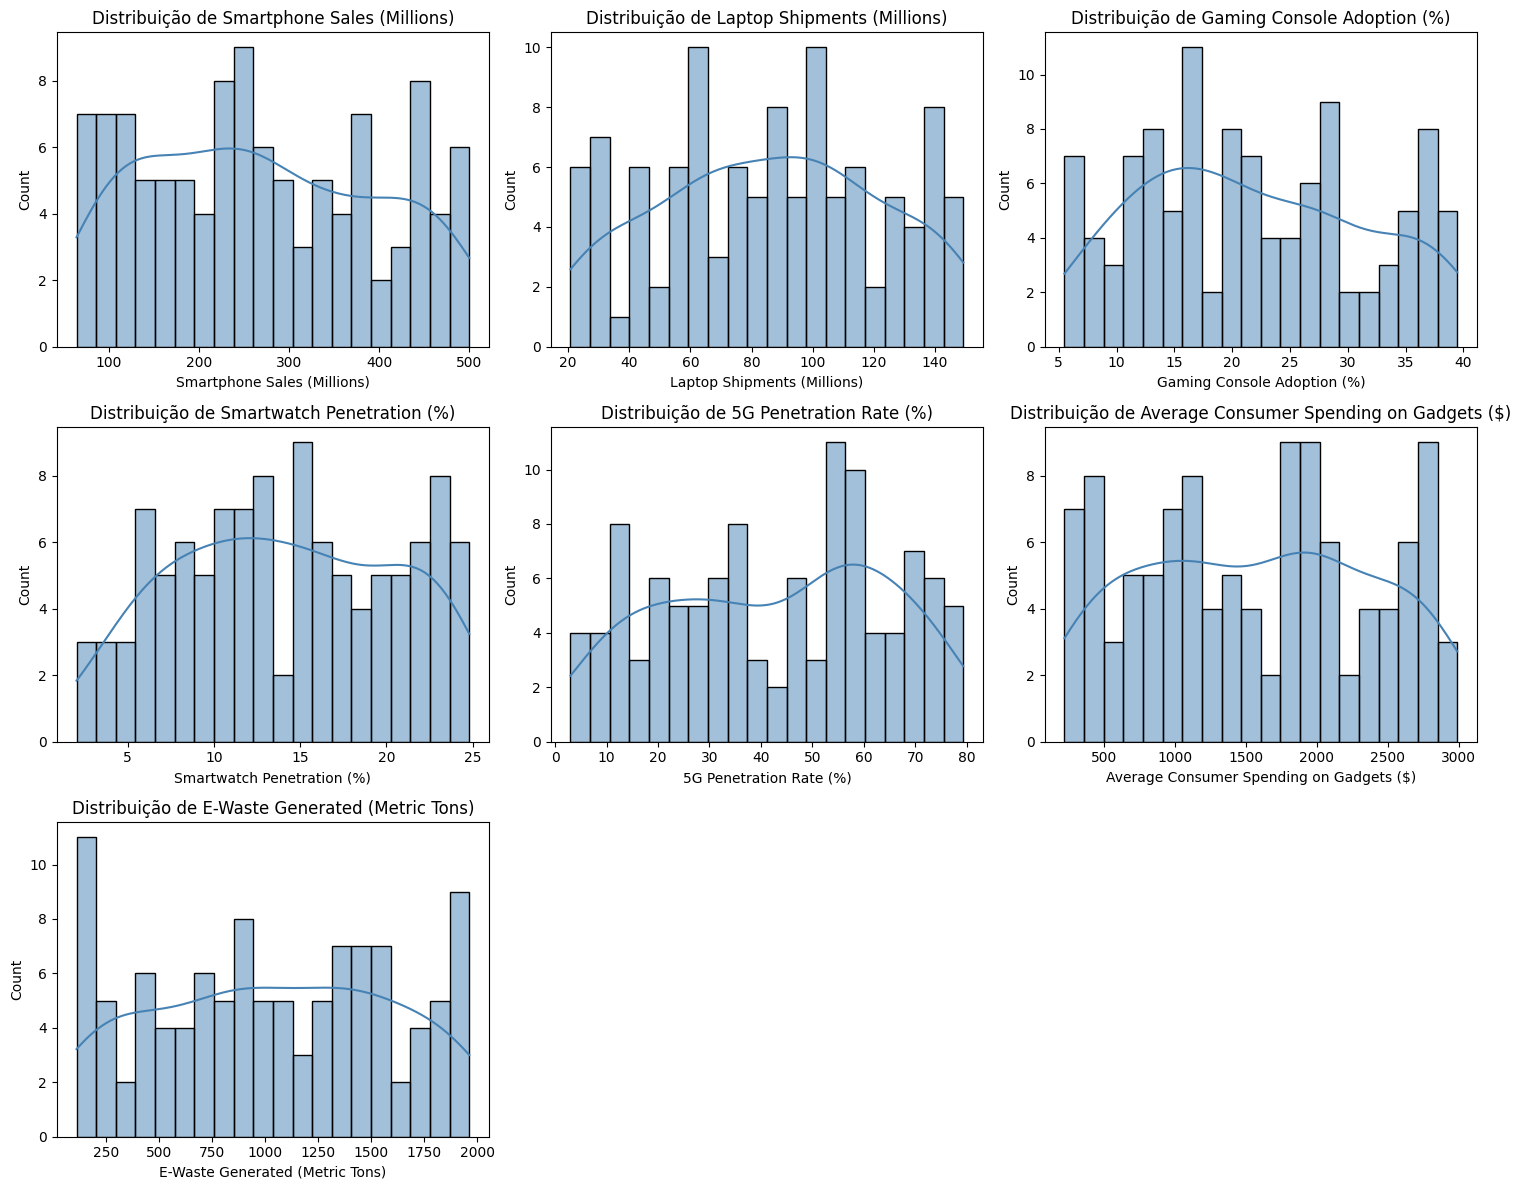

In [ ]:
# → Entender a forma da distribuição
# (normal, enviesada, multimodal)

num_cols = [
    "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)",
    "5G Penetration Rate (%)",
    "Average Consumer Spending on Gadgets ($)",
    "E-Waste Generated (Metric Tons)"
]

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color="steelblue")
    plt.title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()



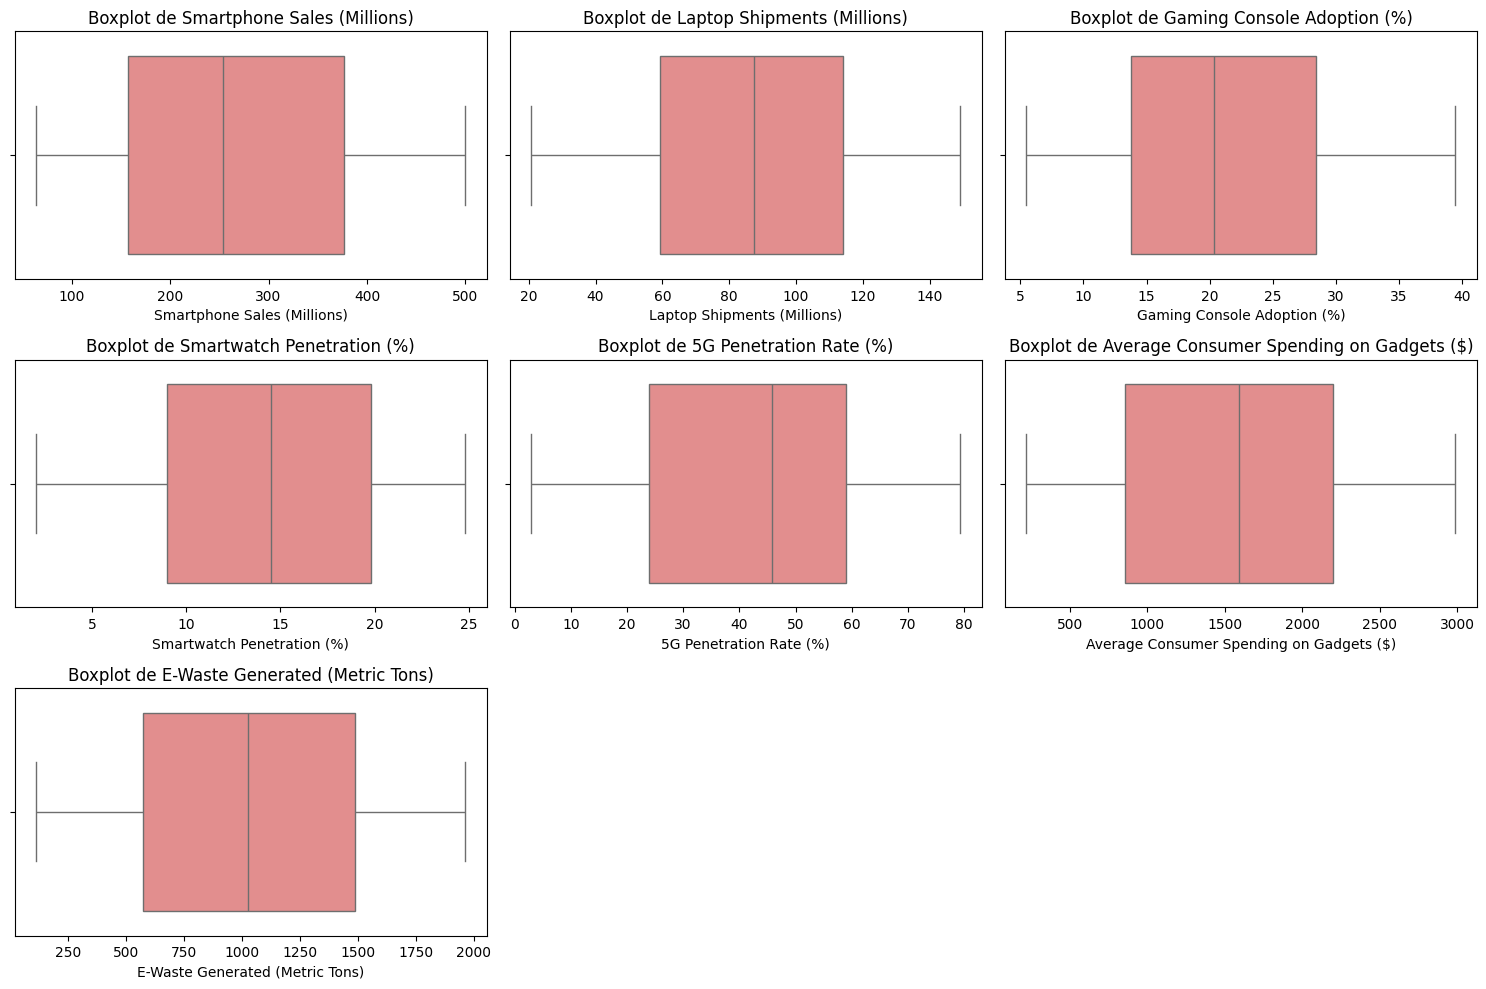

In [ ]:
# → Detectar possíveis outliers univariados.
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


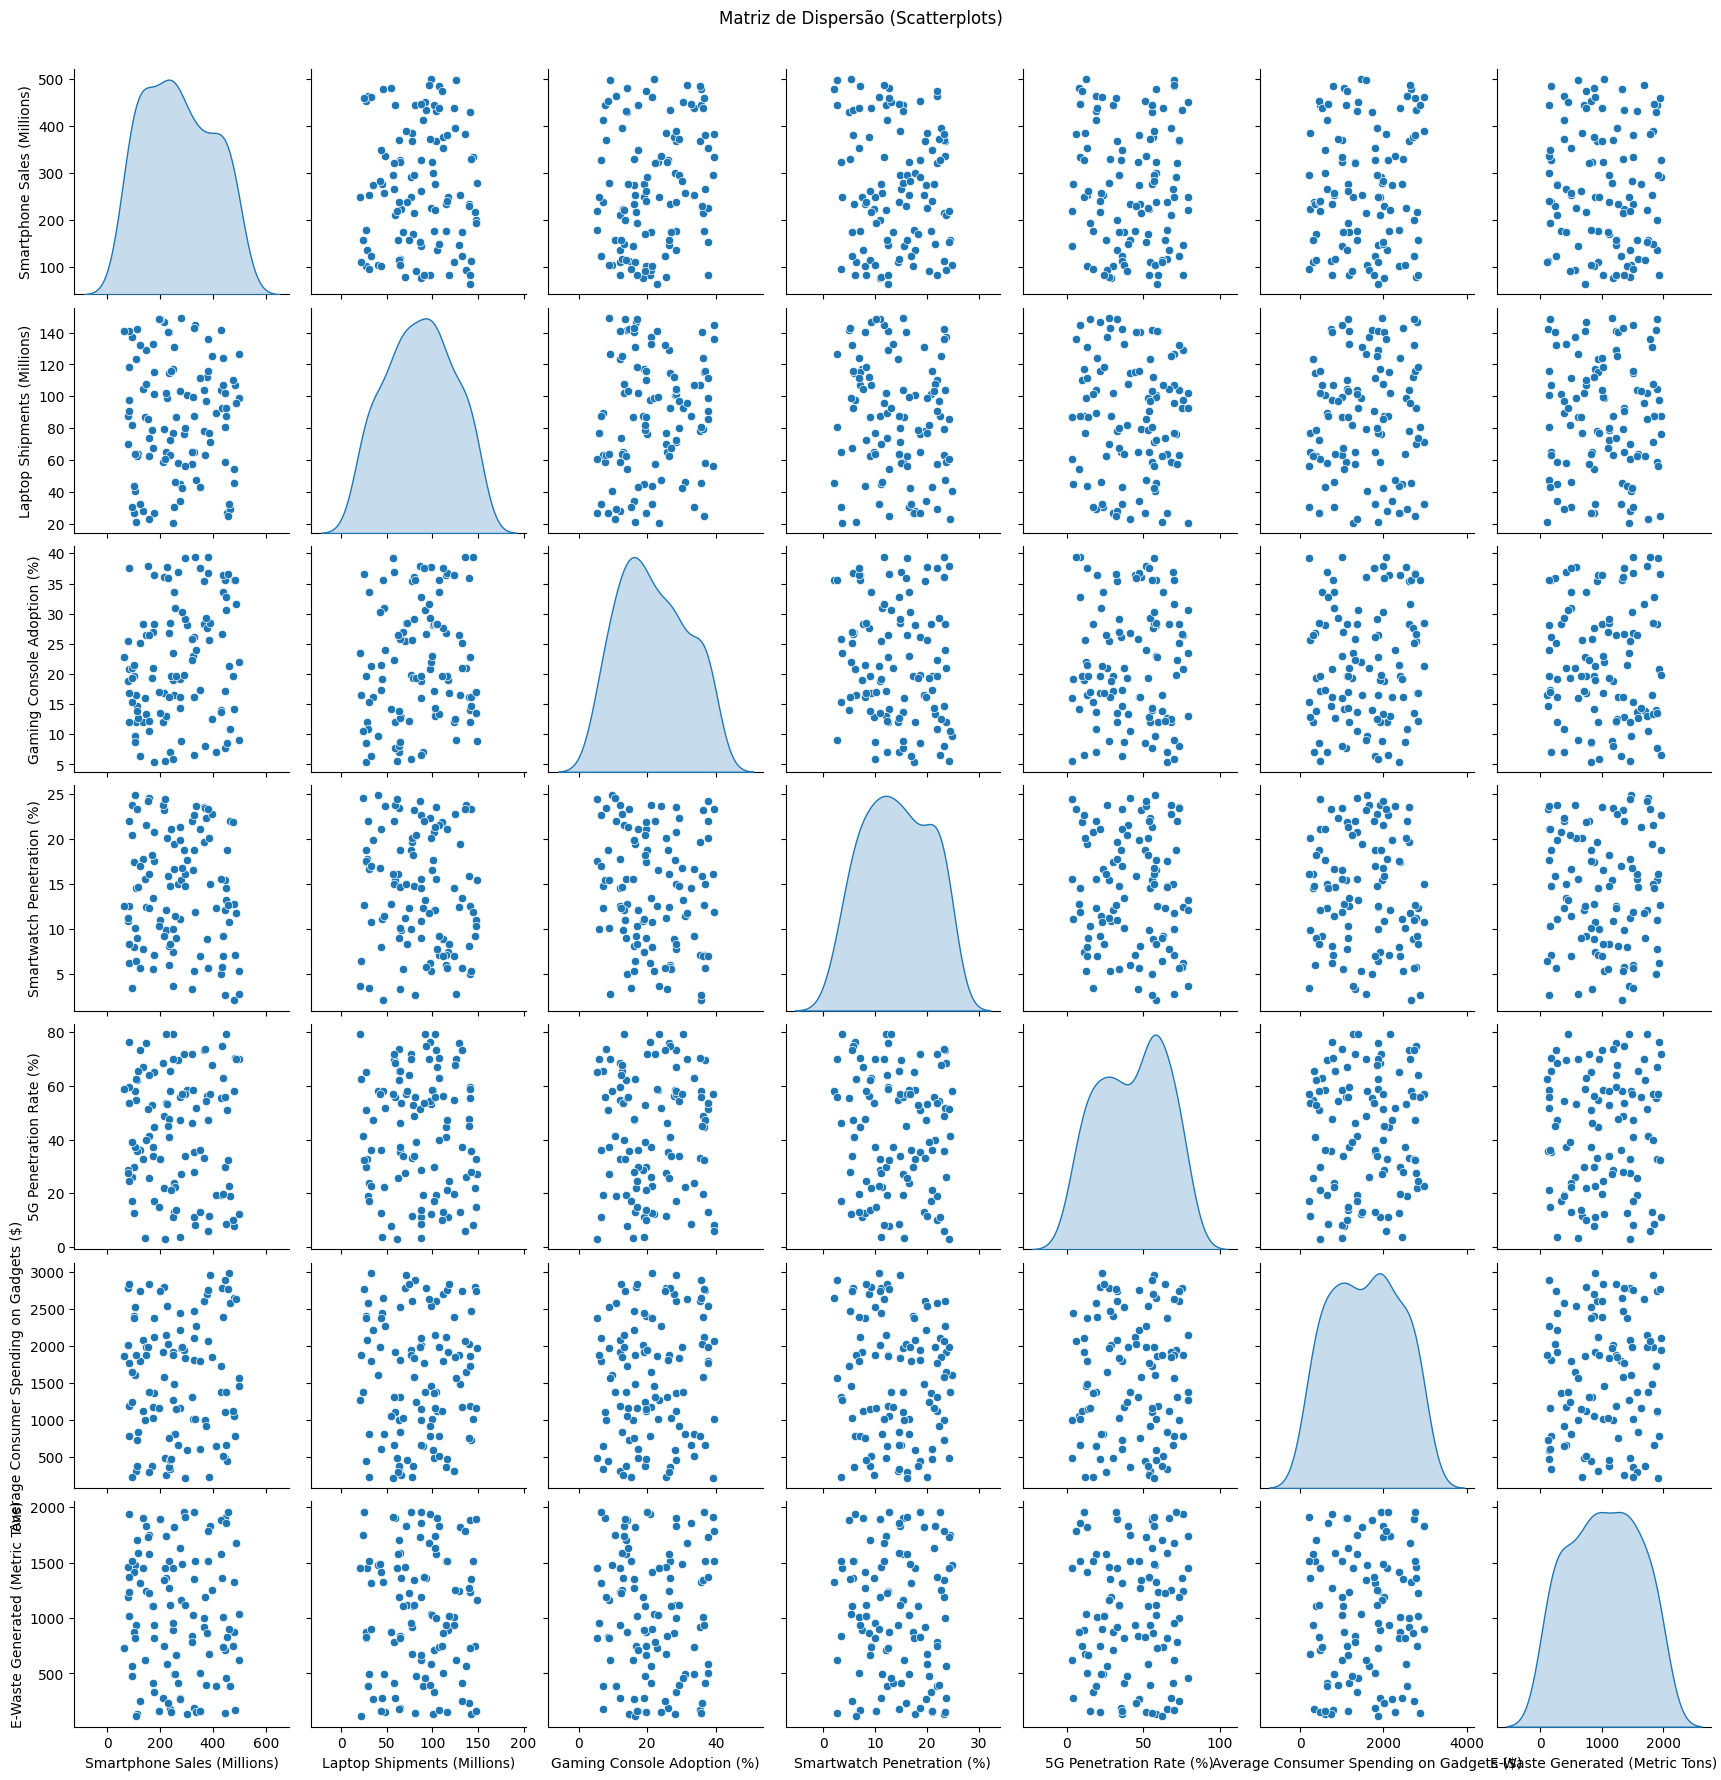

In [ ]:
# → Ver clusters/agrupamentos e outliers
# considerando 2 variáveis ao mesmo tempo.
sns.pairplot(df[num_cols], diag_kind="kde")
plt.suptitle("Matriz de Dispersão (Scatterplots)", y=1.02)
plt.show()


Sustentabilidade
1    26
0    23
Name: count, dtype: int64
Accurácia: 0.60


[Text(0.4230769230769231, 0.9166666666666666, 'Smartwatch Penetration (%) <= 11.935\ngini = 0.5\nsamples = 39\nvalue = [19.5, 19.5]\nclass = Sujo'),
 Text(0.15384615384615385, 0.75, 'Smartphone Sales (Millions) <= 355.78\ngini = 0.404\nsamples = 16\nvalue = [11.917, 4.643]\nclass = Sujo'),
 Text(0.28846153846153844, 0.8333333333333333, 'True  '),
 Text(0.07692307692307693, 0.5833333333333334, 'gini = 0.0\nsamples = 11\nvalue = [11.917, 0.0]\nclass = Sujo'),
 Text(0.23076923076923078, 0.5833333333333334, 'Country_Code <= 3.0\ngini = 0.0\nsamples = 5\nvalue = [0.0, 4.643]\nclass = Verde'),
 Text(0.15384615384615385, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [0.0, 1.857]\nclass = Verde'),
 Text(0.3076923076923077, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0.0, 2.786]\nclass = Verde'),
 Text(0.6923076923076923, 0.75, 'Smartwatch Penetration (%) <= 22.99\ngini = 0.447\nsamples = 23\nvalue = [7.583, 14.857]\nclass = Verde'),
 Text(0.5576923076923077, 0.83333333333333

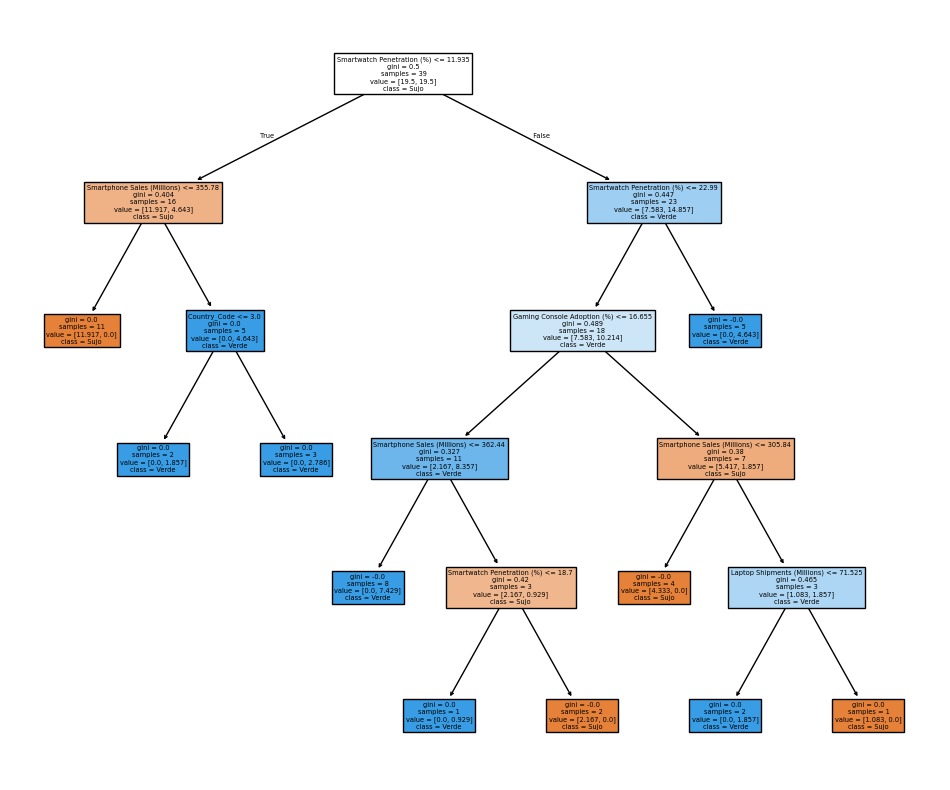

In [ ]:
# Para observar equilíbrio de classes
print(y.value_counts(dropna=False))
# Split, treino, avaliação
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

classifier = tree.DecisionTreeClassifier(random_state=42, class_weight="balanced")  # segue o estilo "padrão"
classifier.fit(x_train, y_train)

accuracy = classifier.score(x_test, y_test)
print(f"Accurácia: {accuracy:.2f}")

# Previsões para usar depois em relatório/matriz
y_pred = classifier.predict(x_test)

plt.figure(figsize=(12, 10))
tree.plot_tree(
    classifier,
    feature_names=X.columns.tolist(),
    class_names=["Sujo", "Verde"],
    filled=True
)

**Sobre a exatidão**

Dado a acurácia de 60% do modelo e e distribuição da maior classe de aproximadamente 53%, tem-se a criação de um padrão não tão óbvio, uma vez que depende de duas variáveis em delta (crescimento gasto × crescimento lixo). Em uma tentativa anterior com os valores invertidos (Verde = gasto cresceu e e-waste não cresceu e sujo = gasto cresceu e e-waste também cresceu), obtinha-se uma acurácia de 67% e com a mesma proporção que o modelo atual. No entanto, dessa forma, o problema fica mais “realista” e consequentemente complexo (já que o aumento de gastos em eletrônicos não necessariamente tem uma relação direta com o aumento e-waste de maneira rápida e subsequente). Ressalta-se que o descarte consciente de eletrônicos corrobora para com a produção de novos aparelhos, pois os componentes, na maior parte das vezes, podem ser reaproveitados. Logo, por mais que houvesse mais acuracidade quando o critério era ΔEwaste ≤ 0 (Verde) e ΔEwaste > 0 (Sujo), conceitualmente, haveria um erro, visto que a premissa de que com menos descarte o crescimento seria mais sustentável (crescem as vendas mas não o descarte - menos reutilização da matéria-prima) é incorreta.

De certo, 60% de acurácia num problema não trivial mostra que o modelo está capturando algo, mas ainda há muito ruído.

Diante do exposto, percebe-se a matriz de confusão.

In [ ]:
# Matriz de confusão
print(classification_report(y_test, y_pred, target_names=["Sujo","Verde"]))
print(confusion_matrix(y_test, y_pred, labels=[0,1]))

#PLOTAR

              precision    recall  f1-score   support

        Sujo       0.60      0.60      0.60         5
       Verde       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10

[[3 2]
 [2 3]]


In [ ]:
# Baseline
print("Distribuição de classes:")
print(y.value_counts().rename({0: "Sujo", 1: "Verde"}))
print("\nProporção (%):")
print((y.value_counts(normalize=True)*100).round(2).rename({0: "Sujo", 1: "Verde"}))


Distribuição de classes:
Sustentabilidade
Verde    26
Sujo     23
Name: count, dtype: int64

Proporção (%):
Sustentabilidade
Verde    53.06
Sujo     46.94
Name: proportion, dtype: float64


**Iniciando a análise**

As **classes** estão **desbalanceadas**?
Ligeiramente, sim. Existe uma leve assimetria que pode afetar o recall da classe menor. Visualiza-se no barplot abaixo da distribuição de classes, o:

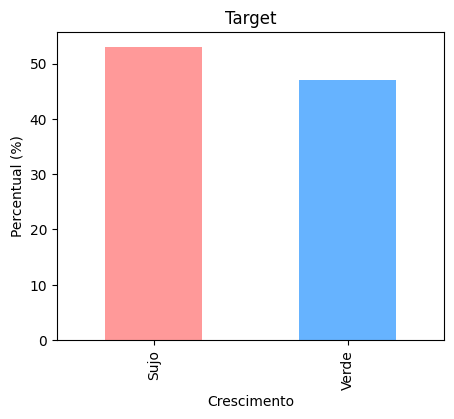

In [ ]:
(y.value_counts(normalize=True)*100).plot(
    kind="bar", color=["#ff9999","#66b3ff"], figsize=(5,4)
)
plt.xticks([0,1], ["Sujo","Verde"])
plt.xlabel("Crescimento")
plt.ylabel("Percentual (%)")
plt.title("Target")
plt.show()

**NOTA:** É possível balancear?


Testa-se com a criação de novos dados para classe minoritária, por meio da ténica de **oversampling (SMOTE)**. Para isso, é necessária simular dados.

E então, refaz-se o modelo com essa alteração.

Distribuição original do treino: Counter({1: 21, 0: 18})
Distribuição após SMOTE: Counter({0: 21, 1: 21})

Acurácia (com SMOTE): 0.60

Relatório de Classificação (SMOTE):
              precision    recall  f1-score   support

        Sujo       0.60      0.60      0.60         5
       Verde       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10



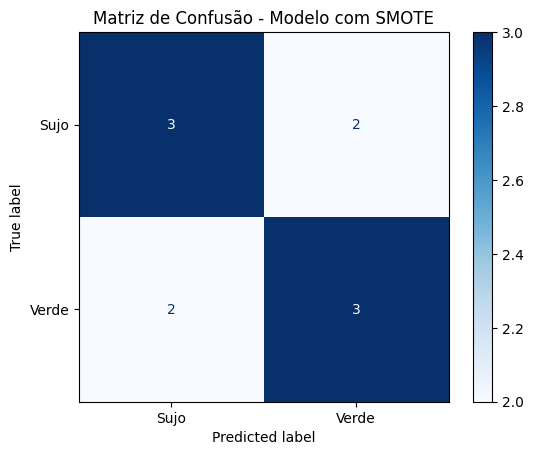

In [ ]:
# ============================================
# PREPROCESS COM NOVA LÓGICA
# ============================================

def preprocess(df):
    # 1) Ordenar por País e Ano
    df = df.sort_values(["Country", "Year"]).copy()

    # 2) Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # 3) Deltas ano a ano por país
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # 4) Classe alvo (NOVA REGRA):
    #    1 = Verde  se ΔSpending > 0 e ΔEwaste > 0
    #    0 = Sujo   se ΔSpending > 0 e ΔEwaste ≤ 0
    #    anos com ΔSpending ≤ 0 ficam sem rótulo
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # 5) Seleção de features
    features = [
        "Smartphone Sales (Millions)",
        "Laptop Shipments (Millions)",
        "Gaming Console Adoption (%)",
        "Smartwatch Penetration (%)",
        "5G Penetration Rate (%)",
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y

# ============================================
# MODELO 2: Árvore de Decisão com Oversampling (SMOTE)
# ============================================
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

# 1) Rodar preprocess
X, y = preprocess(df)

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Mostrar distribuição original
print("Distribuição original do treino:", Counter(y_train))

# 4) Aplicar SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Distribuição após SMOTE:", Counter(y_train_res))

# 5) Treinar classificador balanceado
classifier_smote = tree.DecisionTreeClassifier(random_state=42)
classifier_smote.fit(X_train_res, y_train_res)

# 6) Avaliar no conjunto de teste
y_pred_smote = classifier_smote.predict(X_test)

print(f"\nAcurácia (com SMOTE): {accuracy_score(y_test, y_pred_smote):.2f}")
print("\nRelatório de Classificação (SMOTE):")
print(classification_report(y_test, y_pred_smote, target_names=["Sujo","Verde"]))

# 7) Matriz de confusão
cm = confusion_matrix(y_test, y_pred_smote, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sujo","Verde"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - Modelo com SMOTE")
plt.show()


Apesar da tentativa, nenhum elemento muda. Não há balanceamento.

É provável que o dataset seja pequeno demais para utilizar a técnica escolhida.



**Avaliando o rigor do modelo** original


AUC-ROC: 0.6


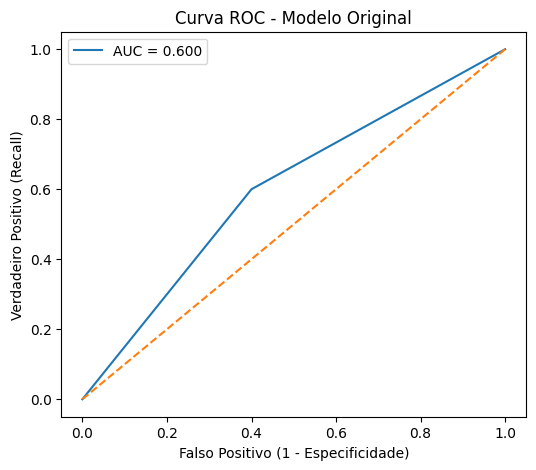

In [ ]:
y_prob = classifier.predict_proba(x_test)[:,1]

print("AUC-ROC:", roc_auc_score(y_test, y_prob))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - Modelo Original")
plt.legend()
plt.show()

Logo, o que pode se fazer para melhorar a previsibilidade do modelo?

1) Tuning: nalisar a complexidade e interpretabilidade e a importância das *features*.

2) Engenharia de *features*.


In [ ]:
# Complexidade e interpretabilidade ---
print("\nProfundidade da árvore:", best_clf.get_depth())
print("Número de folhas:", best_clf.get_n_leaves())

print("Importâncias (features):")
for name, imp in sorted(zip(X.columns, best_clf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

# Curva ROC (mantém apenas visual de separação) ---
# (se ainda não tiver y_prob_best definido, descomente a linha abaixo)
# y_prob_best = best_clf.predict_proba(x_test)[:, 1]

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - Best Decision Tree (GridSearchCV)")
plt.legend()
plt.show()


NameError: name 'best_clf' is not defined

=== MELHOR CONJUNTO (CV, F1 classe 1) ===
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== AVALIAÇÃO NO TESTE (Best Model) ===
Accuracy: 0.6
Balanced Accuracy: 0.6
F1 (classe 1 - Verde): 0.6
F1 (macro): 0.6
AUC-ROC: 0.56

Relatório de Classificação:
               precision    recall  f1-score   support

        Sujo       0.60      0.60      0.60         5
       Verde       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10

Matriz de Confusão:
 [[3 2]
 [2 3]]

Profundidade da árvore: 4
Número de folhas: 7
Importâncias (features):
  Smartphone Sales (Millions): 0.502
  Smartwatch Penetration (%): 0.353
  Gaming Console Adoption (%): 0.145
  5G Penetration Rate (%): 0.000
  Country_Code: 0.000
  Year: 0.000


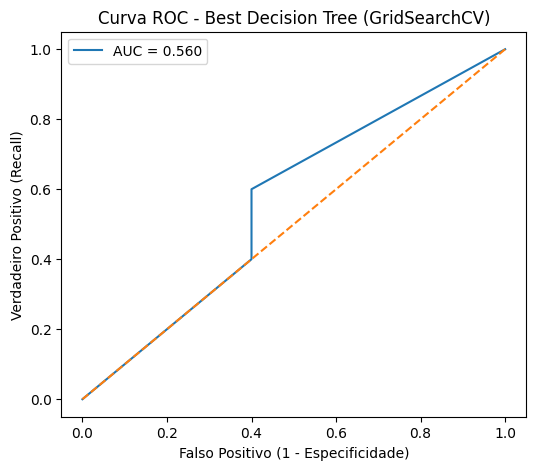

In [ ]:
# ============================================
# PREPROCESS (Verde se ΔSpending > 0 e ΔEwaste > 0)
# ============================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def preprocess(df):
    # 1) Ordenar por País e Ano
    df = df.sort_values(["Country", "Year"]).copy()

    # 2) Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # 3) Deltas ano a ano por país
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # 4) Classe alvo (regra invertida):
    #    1 = Verde  se ΔSpending > 0 e ΔEwaste > 0
    #    0 = Sujo   se ΔSpending > 0 e ΔEwaste ≤ 0
    #    anos com ΔSpending ≤ 0 ficam sem rótulo
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # 5) Features (SEM "Laptop Shipments (Millions)")
    features = [
        "Smartphone Sales (Millions)",
        "Gaming Console Adoption (%)",
        "Smartwatch Penetration (%)",
        "5G Penetration Rate (%)",
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y

# ============================================
# SPLIT TREINO/TESTE
# ============================================
from sklearn.model_selection import train_test_split

# df deve estar carregado previamente, ex.: df = pd.read_csv("Global_Tech_Gadget_Consumption.csv")
X, y = preprocess(df)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# TUNING COM GRIDSEARCHCV (otimizando F1 da minoria = classe 1)
# ============================================
from sklearn import tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer, f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

# scorer F1 da classe minoritária (Verde = 1)
f1_minority = make_scorer(f1_score, pos_label=1)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(x_train, y_train)

print("=== MELHOR CONJUNTO (CV, F1 classe 1) ===")
print(grid.best_params_)

best_clf = grid.best_estimator_

# ============================================
# AVALIAÇÃO NO TESTE
# ============================================
y_pred_best = best_clf.predict(x_test)
y_prob_best = best_clf.predict_proba(x_test)[:, 1]

print("\n=== AVALIAÇÃO NO TESTE (Best Model) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("F1 (classe 1 - Verde):", f1_score(y_test, y_pred_best, pos_label=1))
print("F1 (macro):", f1_score(y_test, y_pred_best, average="macro"))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_best))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_best, target_names=["Sujo","Verde"]))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_best, labels=[0,1]))

# Complexidade e interpretabilidade
print("\nProfundidade da árvore:", best_clf.get_depth())
print("Número de folhas:", best_clf.get_n_leaves())
print("Importâncias (features):")
for name, imp in sorted(zip(X.columns, best_clf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

# ============================================
# CURVA ROC
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - Best Decision Tree (GridSearchCV)")
plt.legend()
plt.show()


**NOTA**: De acordo com o que se foi obitdo no teste de tuning com GridSearch, uma variável é totalmente zerada, a "laptop shipments". Logo, conclui-se que essa é irrelevante. Recria-se o modelo sem a mesma.AUC-ROC se altera.

Em seguida,outra variável também é zerada, mais especificamente "5G Penetration".Pode-se então reescrever novamente o modelo estatístico:

=== MELHOR CONJUNTO (CV, F1 classe 1) ===
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}

=== AVALIAÇÃO NO TESTE (Best Model) ===
Accuracy: 0.6
Balanced Accuracy: 0.6
F1 (classe 1 - Verde): 0.6
F1 (macro): 0.6
AUC-ROC: 0.6

Relatório de Classificação:
               precision    recall  f1-score   support

        Sujo       0.60      0.60      0.60         5
       Verde       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10

Matriz de Confusão:
 [[3 2]
 [2 3]]

Profundidade da árvore: 5
Número de folhas: 8
Importâncias (features):
  Smartphone Sales (Millions): 0.522
  Smartwatch Penetration (%): 0.296
  Gaming Console Adoption (%): 0.182
  Country_Code: 0.000
  Year: 0.000


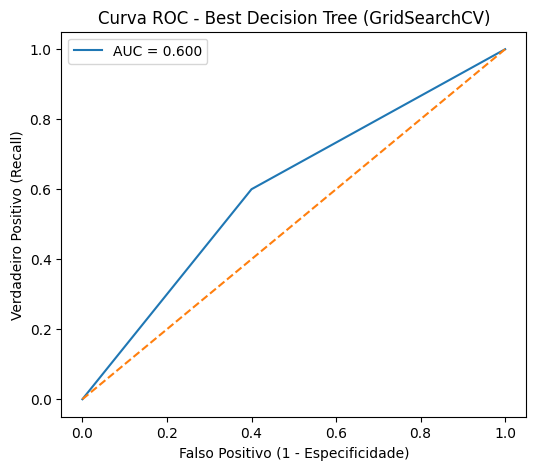

In [ ]:
# ============================================
# PREPROCESS (Verde se ΔSpending > 0 e ΔEwaste > 0)
# ============================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def preprocess(df):
    # 1) Ordenar por País e Ano
    df = df.sort_values(["Country", "Year"]).copy()

    # 2) Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # 3) Deltas ano a ano por país
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # 4) Classe alvo (regra invertida):
    #    1 = Verde  se ΔSpending > 0 e ΔEwaste > 0
    #    0 = Sujo   se ΔSpending > 0 e ΔEwaste <= 0
    #    anos com ΔSpending ≤ 0 ficam sem rótulo
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # 5) Features (SEM "5G Penetration Rate (%)" e já sem "Laptop Shipments (Millions)")
    features = [
        "Smartphone Sales (Millions)",
        "Gaming Console Adoption (%)",
        "Smartwatch Penetration (%)",
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y

# ============================================
# SPLIT TREINO/TESTE
# ============================================
from sklearn.model_selection import train_test_split

# df deve estar carregado previamente
X, y = preprocess(df)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# TUNING COM GRIDSEARCHCV (otimizando F1 da minoria = classe 1)
# ============================================
from sklearn import tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer, f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

# scorer F1 da classe minoritária (Verde = 1)
f1_minority = make_scorer(f1_score, pos_label=1)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(x_train, y_train)

print("=== MELHOR CONJUNTO (CV, F1 classe 1) ===")
print(grid.best_params_)

best_clf = grid.best_estimator_

# ============================================
# AVALIAÇÃO NO TESTE
# ============================================
y_pred_best = best_clf.predict(x_test)
y_prob_best = best_clf.predict_proba(x_test)[:, 1]

print("\n=== AVALIAÇÃO NO TESTE (Best Model) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("F1 (classe 1 - Verde):", f1_score(y_test, y_pred_best, pos_label=1))
print("F1 (macro):", f1_score(y_test, y_pred_best, average="macro"))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_best))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_best, target_names=["Sujo","Verde"]))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_best, labels=[0,1]))

# Complexidade e interpretabilidade
print("\nProfundidade da árvore:", best_clf.get_depth())
print("Número de folhas:", best_clf.get_n_leaves())
print("Importâncias (features):")
for name, imp in sorted(zip(X.columns, best_clf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

# ============================================
# CURVA ROC
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - Best Decision Tree (GridSearchCV)")
plt.legend()
plt.show()


No entanto, a acurácia ainda permanece a mesma.

E se a única referência for "smartphone sales" (millions)?
A seguir o resultado do teste.

=== MELHOR CONJUNTO (CV, F1 classe 1) ===
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}

=== AVALIAÇÃO NO TESTE (Best Model) ===
Accuracy: 0.3
Balanced Accuracy: 0.3
F1 (classe 1 - Verde): 0.46153846153846156
F1 (macro): 0.23076923076923078
AUC-ROC: 0.44000000000000006

Relatório de Classificação:
               precision    recall  f1-score   support

        Sujo       0.00      0.00      0.00         5
       Verde       0.38      0.60      0.46         5

    accuracy                           0.30        10
   macro avg       0.19      0.30      0.23        10
weighted avg       0.19      0.30      0.23        10

Matriz de Confusão:
 [[0 5]
 [2 3]]

Profundidade da árvore: 3
Número de folhas: 4
Importâncias (features):
  Smartphone Sales (Millions): 0.698
  Year: 0.302
  Country_Code: 0.000


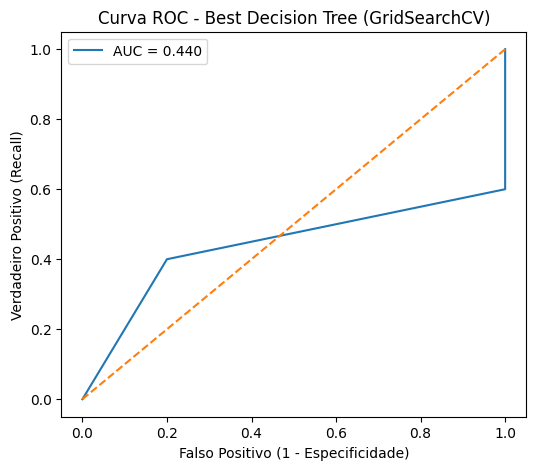

In [ ]:
# ============================================
# PREPROCESS (Verde se ΔSpending > 0 e ΔEwaste > 0)
# ============================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder

def preprocess(df):
    # 1) Ordenar por País e Ano
    df = df.sort_values(["Country", "Year"]).copy()

    # 2) Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # 3) Deltas ano a ano por país
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # 4) Classe alvo (regra invertida):
    #    1 = Verde  se ΔSpending > 0 e ΔEwaste > 0
    #    0 = Sujo   se ΔSpending > 0 e ΔEwaste <= 0
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # 5) Features (apenas Smartphones + País + Ano)
    features = [
        "Smartphone Sales (Millions)",
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y

# ============================================
# SPLIT TREINO/TESTE
# ============================================
from sklearn.model_selection import train_test_split

# df deve estar carregado previamente
X, y = preprocess(df)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# TUNING COM GRIDSEARCHCV (otimizando F1 da minoria = classe 1)
# ============================================
from sklearn import tree
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer, f1_score, accuracy_score, balanced_accuracy_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

# scorer F1 da classe minoritária (Verde = 1)
f1_minority = make_scorer(f1_score, pos_label=1)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(x_train, y_train)

print("=== MELHOR CONJUNTO (CV, F1 classe 1) ===")
print(grid.best_params_)

best_clf = grid.best_estimator_

# ============================================
# AVALIAÇÃO NO TESTE
# ============================================
y_pred_best = best_clf.predict(x_test)
y_prob_best = best_clf.predict_proba(x_test)[:, 1]

print("\n=== AVALIAÇÃO NO TESTE (Best Model) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("F1 (classe 1 - Verde):", f1_score(y_test, y_pred_best, pos_label=1))
print("F1 (macro):", f1_score(y_test, y_pred_best, average="macro"))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_best))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_best, target_names=["Sujo","Verde"]))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_best, labels=[0,1]))

# Complexidade e interpretabilidade
print("\nProfundidade da árvore:", best_clf.get_depth())
print("Número de folhas:", best_clf.get_n_leaves())
print("Importâncias (features):")
for name, imp in sorted(zip(X.columns, best_clf.feature_importances_), key=lambda t: -t[1]):
    print(f"  {name}: {imp:.3f}")

# ============================================
# CURVA ROC
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - Best Decision Tree (GridSearchCV)")
plt.legend()
plt.show()


Resposta: Os dados ficam mais imprecisos.

Diante do exposto, é mais lógico usar o modelo em que "laptop shipments' não é mais feature enquanto "5G penetration" ainda é.

**Conclusão**

In [ ]:
# Criação de um novo dataframe para plot das informações de classificação quanto a sustentabilidade

# Parte 1) copiar e garantir ordenação
df_sustentability = df.sort_values(["Country", "Year"]).copy()

# Parte 2) codificar Country (opcional, se precisar do código do país)
le = LabelEncoder()
df_sustentability["Country_Code"] = le.fit_transform(df_sustentability["Country"])

# Parte 3) deltas por país (mesma lógica do preprocess)
df_sustentability["Delta_Spending"] = df_sustentability.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
df_sustentability["Delta_Ewaste"]   = df_sustentability.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

# Parte 4) classe Sustentabilidade (igual ao seu target)
def classify_growth(row):
    if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
        return 1 if row["Delta_Ewaste"] <= 0 else 0
    return None

df_sustentability["Sustentabilidade"] = df_sustentability.apply(classify_growth, axis=1)
df_sustentability = df_sustentability.dropna(subset=["Sustentabilidade"]).copy()
df_sustentability["Sustentabilidade"] = df_sustentability["Sustentabilidade"].astype(int)
df_sustentability = df_sustentability.set_index("Year")


print(df_sustentability.head())


     Country  Smartphone Sales (Millions)  Laptop Shipments (Millions)  \
Year                                                                     
2017  Brazil                       327.88                        87.59   
2018  Brazil                       329.09                       142.58   
2021  Brazil                       397.00                       125.19   
2022  Brazil                        82.81                       118.43   
2024  Brazil                       158.13                        74.04   

      Gaming Console Adoption (%)  Smartwatch Penetration (%)  \
Year                                                            
2017                         6.58                       22.57   
2018                        16.16                        5.26   
2021                        12.59                       22.75   
2022                        16.92                        8.27   
2024                        12.23                       12.24   

      Average Consumer Sp

**NOTA**: só anos com ΔSpending > 0 entram no jogo
-
Por que alguns anos (2019, 2020, 2023 para o Brasil) não aparecem?

Isso acontece porque na função classify_growth, foi definid a regra:

Só cria classe (Sustentabilidade) se ΔSpending > 0. (por ano)

Linhas em que ΔSpending <= 0 → recebem None.

Depois usamos dropna(subset=["Sustentabilidade"]).

Ou seja:

O ano só entra no df_sustentability se houve crescimento positivo de gasto em relação ao ano anterior.

Se o Brasil teve gasto estável ou queda nesses anos, eles foram removidos.

Portanto, não é que o dado esteja ausente no dataset original, é a regra de classificação que excluiu esses anos.

**Predominância** de crescimento sujo x verde

Resumo por país (contagem, proporção de Verde e predominância):


,Sujo,Verde,prop_verde,Predominancia
Country,,,,
UK,1,4,0.800000,Predominante Verde
Canada,1,3,0.750000,Predominante Verde
India,1,3,0.750000,Predominante Verde
China,2,4,0.666667,Predominante Verde
Germany,3,4,0.571429,Predominante Verde
USA,2,2,0.500000,Empate
South Korea,2,2,0.500000,Empate
Brazil,3,2,0.400000,Predominante Sujo
France,4,1,0.200000,Predominante Sujo


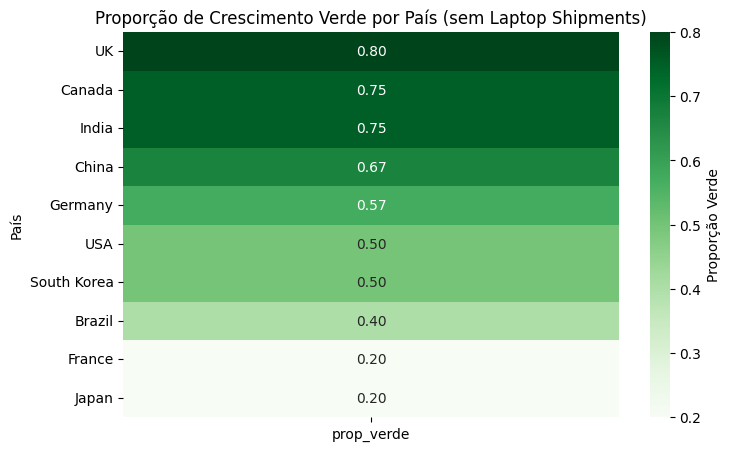

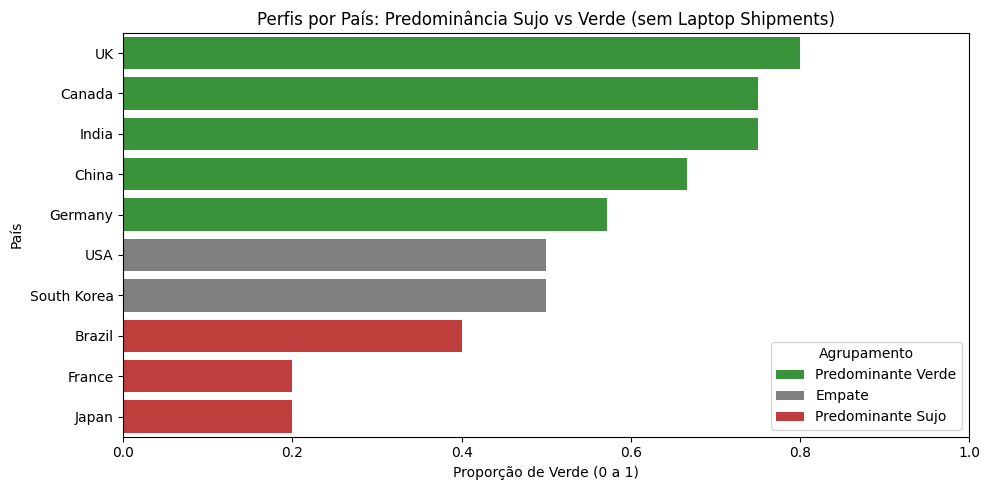

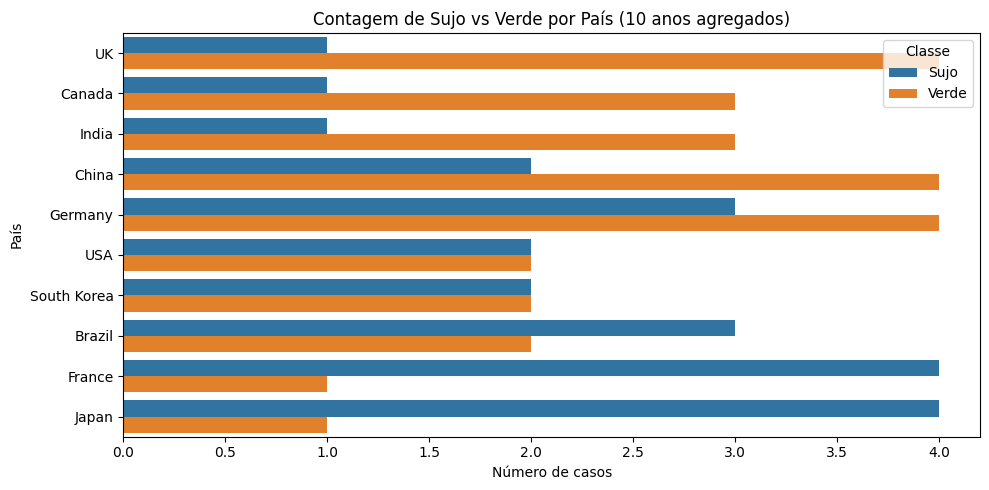

In [ ]:
# Determinação se o perfil país em maior crescimento predominante sujo ou verde
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# -----------------------------
# 1) Recalcular Sustentabilidade no mesmo padrão do modelo (sem Laptop Shipments)
# -----------------------------
df_tmp = df.sort_values(["Country","Year"]).copy()

# codificação país
le = LabelEncoder()
df_tmp["Country_Code"] = le.fit_transform(df_tmp["Country"])

# deltas
df_tmp["Delta_Spending"] = df_tmp.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
df_tmp["Delta_Ewaste"]   = df_tmp.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

def classify_growth(row):
    if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
        return 1 if row["Delta_Ewaste"] > 0 else 0  # Verde=1, Sujo=0
    return None

df_tmp["Sustentabilidade"] = df_tmp.apply(classify_growth, axis=1)
df_tmp = df_tmp.dropna(subset=["Sustentabilidade"]).copy()
df_tmp["Sustentabilidade"] = df_tmp["Sustentabilidade"].astype(int)

# -----------------------------
# 2) Resumo por país
# -----------------------------
ct = df_tmp.groupby(["Country","Sustentabilidade"]).size().unstack(fill_value=0)
ct = ct.rename(columns={0:"Sujo", 1:"Verde"})
prop = df_tmp.groupby("Country")["Sustentabilidade"].mean().to_frame("prop_verde")
summary = ct.join(prop)

def predom(row):
    if row["Verde"] > row["Sujo"]:
        return "Predominante Verde"
    elif row["Sujo"] > row["Verde"]:
        return "Predominante Sujo"
    else:
        return "Empate"

summary["Predominancia"] = summary.apply(predom, axis=1)
summary = summary.sort_values("prop_verde", ascending=False)

print("Resumo por país (contagem, proporção de Verde e predominância):")
display(summary)

# -----------------------------
# 3) Plots
# -----------------------------

# Heatmap proporção Verde
plt.figure(figsize=(8, max(4, 0.5*len(summary))))
sns.heatmap(summary[["prop_verde"]], annot=True, fmt=".2f", cmap="Greens", cbar_kws={"label":"Proporção Verde"})
plt.title("Proporção de Crescimento Verde por País")
plt.xlabel("")
plt.ylabel("País")
plt.show()

# Barras ordenadas por proporção (agrupadas por predominância)
palette = {
    "Predominante Verde": "#2ca02c",
    "Predominante Sujo": "#d62728",
    "Empate": "#7f7f7f"
}

plt.figure(figsize=(10, max(4, 0.5*len(summary))))
sns.barplot(
    data=summary.reset_index(),
    x="prop_verde", y="Country",
    hue="Predominancia", dodge=False, palette=palette, order=summary.reset_index()["Country"]
)
plt.xlim(0,1)
plt.xlabel("Proporção de Verde (0 a 1)")
plt.ylabel("País")
plt.title("Perfis por País: Predominância Sujo vs Verde (sem Laptop Shipments)")
plt.legend(title="Agrupamento")
plt.tight_layout()
plt.show()

# Barras empilhadas Sujo x Verde por país
stack_df = summary[["Sujo","Verde"]].reset_index().melt(id_vars="Country", var_name="Classe", value_name="count")
plt.figure(figsize=(10, max(4, 0.5*len(summary))))
sns.barplot(data=stack_df, x="count", y="Country", hue="Classe", hue_order=["Sujo","Verde"], order=summary.index)
plt.title("Cresciimento Sujo vs Verde por País (10 anos agregados)")
plt.xlabel("Número de casos")
plt.ylabel("País")
plt.tight_layout()
plt.show()


Implementando KNN

=== KNN: Melhor conjunto (CV, F1 classe 1) ===
{'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}

=== KNN | Avaliação no TESTE ===
Accuracy: 0.5
Balanced Accuracy: 0.5
F1 (classe 1 - Verde): 0.5454545454545454
F1 (macro): 0.4949494949494949
AUC-ROC: 0.52

Relatório de Classificação:
               precision    recall  f1-score   support

        Sujo       0.50      0.40      0.44         5
       Verde       0.50      0.60      0.55         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10

Matriz de Confusão:
 [[2 3]
 [2 3]]


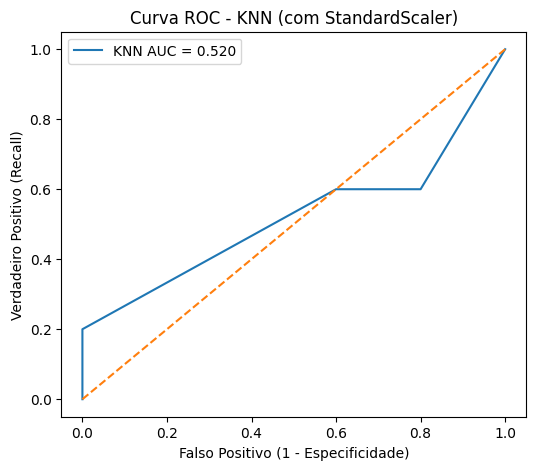

In [ ]:
# Assuming df is already loaded and preprocess function is defined in a previous cell

# Preprocess the data and split into training and testing sets
X, y = preprocess(df)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# pipeline: padroniza features e aplica KNN
pipe_knn = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# busca de hiperparâmetros (foco em F1 da minoria = classe 1)
param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],                      # 1=Manhattan, 2=Euclidiana
    "knn__leaf_size": [15, 30, 45]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_minority = make_scorer(f1_score, pos_label=1)

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid_knn.fit(x_train, y_train)

print("=== KNN: Melhor conjunto (CV, F1 classe 1) ===")
print(grid_knn.best_params_)

best_knn = grid_knn.best_estimator_

# -------- Avaliação no TESTE --------
y_pred_knn = best_knn.predict(x_test)
y_prob_knn = best_knn.predict_proba(x_test)[:, 1]

print("\n=== KNN | Avaliação no TESTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))
print("F1 (classe 1 - Verde):", f1_score(y_test, y_pred_knn, pos_label=1))
print("F1 (macro):", f1_score(y_test, y_pred_knn, average="macro"))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_knn))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_knn, target_names=["Sujo","Verde"]))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_knn, labels=[0,1]))

# Curva ROC do KNN
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KNN AUC = {roc_auc_score(y_test, y_prob_knn):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - KNN (com StandardScaler)")
plt.legend()
plt.show()


Note que com GridSearchCV, escolhe-se qual a melhor métrica de distância para atuar no cenário em questão (p=1 ou p=2 ou p=3).

In [ ]:
print(grid_knn.best_params_)


{'knn__leaf_size': 15, 'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}


A métrica que mais tem sentido usar é a distância euclidiana (p=2), visto que F1 Score fica mais realista de acordo com a biblioteca. Ao olhar para matriz de confusão, isso se confirma.

In [ ]:
# TESTE
# VISUALIZAÇÃO 2D DO KNN (fronteira de decisão)
# Usando: Smartphone Sales (Millions) vs Year
# ============================================


# --- 1) Recriar rótulo Sustentabilidade (mesma regra do seu pipeline) ---
df_vis = df.sort_values(["Country","Year"]).copy()

df_vis["Delta_Spending"] = df_vis.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
df_vis["Delta_Ewaste"]   = df_vis.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

def classify_growth(row):
    if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
        return 1 if row["Delta_Ewaste"] > 0 else 0  # Verde=1, Sujo=0
    return None

df_vis["Sustentabilidade"] = df_vis.apply(classify_growth, axis=1)
df_vis = df_vis.dropna(subset=["Sustentabilidade"]).copy()
df_vis["Sustentabilidade"] = df_vis["Sustentabilidade"].astype(int)

# --- 2) Selecionar apenas duas features para o plot 2D ---
feat_x = "Smartphone Sales (Millions)"
feat_y = "Year"

X2 = df_vis[[feat_x, feat_y]].to_numpy()
y2 = df_vis["Sustentabilidade"].to_numpy()

# --- 3) Padronizar (KNN precisa de escala comparável) ---
scaler = StandardScaler()
X2s = scaler.fit_transform(X2)

# --- 4) Função para plotar fronteira de decisão ---
def plot_knn_decision_boundary(Xs, y, k=5, weights="uniform", ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6,5))
    # Treina KNN
    knn = KNeighborsClassifier(n_neighbors=k, weights=weights)
    knn.fit(Xs, y)

    # Gera malha no espaço padronizado
    x_min, x_max = Xs[:,0].min()-0.5, Xs[:,0].max()+0.5
    y_min, y_max = Xs[:,1].min()-0.5, Xs[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Paleta: 0=Sujo (vermelho), 1=Verde (verde)
    cmap_bg = ListedColormap(["#f7c6c6", "#c9eac9"])
    cmap_pts = ListedColormap(["#d62728", "#2ca02c"])

    # Fundo = regiões de decisão (no espaço padronizado)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_bg)

    # Pontos reais (no espaço padronizado)
    scatter = ax.scatter(Xs[:,0], Xs[:,1], c=y, cmap=cmap_pts, edgecolor="k", s=50, alpha=0.9)

    # Eixos com rótulos originais (despadroniza grade apenas para ticks)
    # -> vamos definir ticks nas escalas originais para facilitar a leitura
    # eixo X (Smartphones)
    xticks_std = ax.get_xticks()
    xticks_orig = scaler.inverse_transform(np.c_[xticks_std, np.zeros_like(xticks_std)])[:,0]
    ax.set_xticks(xticks_std)
    ax.set_xticklabels([f"{v:.0f}" for v in xticks_orig])
    ax.set_xlabel(feat_x)

    # eixo Y (Year)
    yticks_std = ax.get_yticks()
    yticks_orig = scaler.inverse_transform(np.c_[np.zeros_like(yticks_std), yticks_std])[:,1]
    ax.set_yticks(yticks_std)
    ax.set_yticklabels([f"{int(v)}" for v in yticks_orig])
    ax.set_ylabel(feat_y)

    ax.set_title(title or f"KNN decision boundary (k={k}, weights='{weights}')")
    # legenda
    handles = [plt.Line2D([],[], marker='o', color='w', markerfacecolor="#d62728", markeredgecolor='k', markersize=8, label='Sujo (0)'),
               plt.Line2D([],[], marker='o', color='w', markerfacecolor="#2ca02c", markeredgecolor='k', markersize=8, label='Verde (1)')]
    ax.legend(handles=handles, loc="best")

    return knn

# --- 5) Plots lado a lado com k diferentes (como no material do professor) ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_knn_decision_boundary(X2s, y2, k=3,  weights="uniform",  ax=axes[0], title="KNN (k=3, weights='uniform')")
plot_knn_decision_boundary(X2s, y2, k=11, weights="distance", ax=axes[1], title="KNN (k=11, weights='distance')")
plt.tight_layout()
plt.show()

Como é um teste, está ok. Identificamos que K deve ser bem maior do que 3, apenas com 11, as áreas de influência ficaram corretas.
Se fosse treino, seria sinal de overfitting. E como solução, poderíamos aumentar o bias e diminuir variabilidade. Vejamos agora.

["Average Consumer Spending on Gadgets ($)"].diff()
df_sustentability["Delta_Ewaste"]   = df_sustentability.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()